# Machine Learning Algorithms Summary
## Complete Guide with Detailed Comments
Comprehensive code blocks for all ML algorithms extracted from 5 Jupyter notebooks

In [4]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report

print("All libraries imported successfully!")

All libraries imported successfully!


# 1. K-Nearest Neighbors (kNN) - CLASSIFICATION

kNN Classification is a non-parametric, instance-based learning algorithm that 
classifies a new data point based on the majority class of its k nearest neighbors.

**Key Concepts:**
- Distance-based algorithm (usually Euclidean distance)
- No training phase - just stores training data
- Prediction time is slower than other algorithms
- Sensitive to feature scaling
- k is a critical hyperparameter

In [5]:
from sklearn.neighbors import KNeighborsClassifier  # Import kNN classifier from scikit-learn
from sklearn.datasets import load_iris  # Load the iris dataset

# Load sample dataset
iris_dataset = load_iris()  # Store the iris data
X = iris_dataset['data']  # Extract feature variables (shape: 150, 4)
y = iris_dataset['target']  # Extract target variable (species: 0, 1, 2)

# Split data into training (75%) and test (25%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,  # Features and target
    test_size=0.25,  # Use 25% of data for testing
    random_state=0  # Fixed seed for reproducibility
)

# Initialize kNN classifier with k=3 neighbors
knn = KNeighborsClassifier(n_neighbors=3)  # Create classifier object, k=3 is default

# Train the model on training data
knn.fit(X_train, y_train)  # Fit model to training features and target

# Make predictions on test set
y_pred = knn.predict(X_test)  # Predict target for test features

# Evaluate model performance
accuracy = knn.score(X_test, y_test)  # Calculate accuracy score
print(f"Test set accuracy: {accuracy:.2f}")  # Print accuracy as percentage

# Test on a new sample
X_new = np.array([[5, 2.9, 1, 0.2]])  # Create a new sample (1 sample, 4 features)
prediction = knn.predict(X_new)  # Predict class of new sample
print(f"Prediction: {iris_dataset['target_names'][prediction[0]]}")  # Print species name

Test set accuracy: 0.97
Prediction: setosa


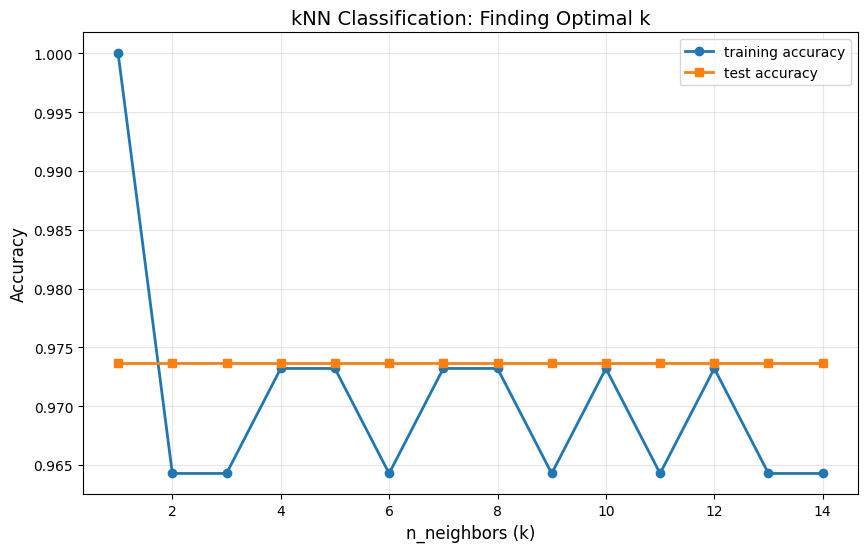

Best k value: 1 with test accuracy: 0.9737


In [6]:
# Test different values of k neighbors and find the best one
training_accuracy = []  # Store training accuracy for each k
test_accuracy = []  # Store test accuracy for each k
neighbors_settings = range(1, 15)  # Try k values from 1 to 14

for n_neighbors in neighbors_settings:
    # Create classifier with specific k value
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    
    # Train classifier on training data
    clf.fit(X_train, y_train)
    
    # Record training set accuracy (how well it fits training data)
    training_accuracy.append(clf.score(X_train, y_train))
    
    # Record test set accuracy (generalization performance)
    test_accuracy.append(clf.score(X_test, y_test))

# Plot results to visualize overfitting/underfitting
plt.figure(figsize=(10, 6))
plt.plot(neighbors_settings, training_accuracy, marker='o', label="training accuracy", linewidth=2)  # Blue line
plt.plot(neighbors_settings, test_accuracy, marker='s', label="test accuracy", linewidth=2)  # Orange line
plt.ylabel("Accuracy", fontsize=12)  # Y-axis label
plt.xlabel("n_neighbors (k)", fontsize=12)  # X-axis label
plt.title("kNN Classification: Finding Optimal k", fontsize=14)
plt.legend(fontsize=10)  # Display legend
plt.grid(True, alpha=0.3)
plt.show()

# Find best k
best_k = neighbors_settings[np.argmax(test_accuracy)]
print(f"Best k value: {best_k} with test accuracy: {max(test_accuracy):.4f}")

# 2. K-Nearest Neighbors (kNN) - REGRESSION

kNN Regression predicts continuous target values based on the average value of 
the k nearest neighbors.

**Key Differences from Classification:**
- Outputs are averaged instead of voted on
- Uses R² score instead of accuracy
- Better for continuous predictions

Test set R² score: -1.5115


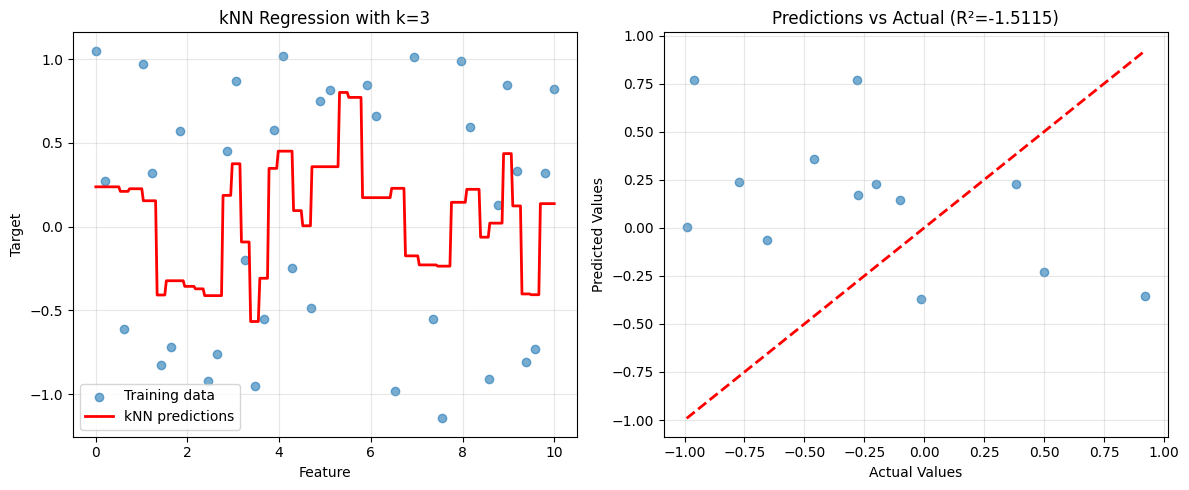

In [7]:
from sklearn.neighbors import KNeighborsRegressor  # Import kNN regressor

# Create simple regression dataset
np.random.seed(42)
X_reg = np.linspace(0, 10, 50).reshape(-1, 1)  # 50 points from 0 to 10
y_reg = np.cos(2 * np.pi * X_reg.flatten()) + np.random.normal(0, 0.1, 50)  # Cosine with noise

# Split into training and test sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,  # Features and target values
    test_size=0.25,  # 25% for testing
    random_state=0  # Fixed seed
)

# Initialize and train regressor with k=3
reg = KNeighborsRegressor(n_neighbors=3)  # Create regressor with 3 neighbors
reg.fit(X_train_reg, y_train_reg)  # Train on training data

# Make predictions
y_pred_reg = reg.predict(X_test_reg)  # Predict continuous values for test set

# Evaluate performance
r2_score = reg.score(X_test_reg, y_test_reg)  # Calculate R² score (coefficient of determiSnation)
print(f"Test set R² score: {r2_score:.4f}")  # Print R² value

# Visualize predictions
plt.figure(figsize=(12, 5))

# Plot 1: Training data and predictions
plt.subplot(1, 2, 1)
plt.scatter(X_train_reg, y_train_reg, alpha=0.6, label='Training data')
X_line = np.linspace(0, 10, 300).reshape(-1, 1)
y_line = reg.predict(X_line)
plt.plot(X_line, y_line, 'r-', linewidth=2, label='kNN predictions')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('kNN Regression with k=3')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Predictions vs Actual
plt.subplot(1, 2, 2)
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Predictions vs Actual (R²={r2_score:.4f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

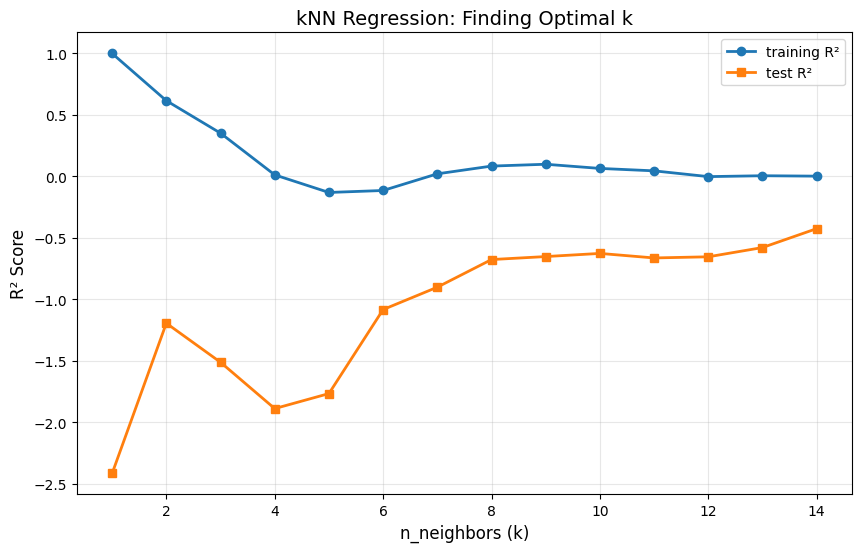

Best k value: 14 with test R²: -0.4247


In [8]:
# Test different k values for regression
training_r2 = []  # Store R² for training data
test_r2 = []  # Store R² for test data
neighbors_settings = range(1, 15)  # Try k from 1 to 14

for n_neighbors in neighbors_settings:
    # Create regressor with current k value
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    
    # Train on training data
    reg.fit(X_train_reg, y_train_reg)
    
    # Store training R² score
    training_r2.append(reg.score(X_train_reg, y_train_reg))
    
    # Store test R² score
    test_r2.append(reg.score(X_test_reg, y_test_reg))

# Visualize results
plt.figure(figsize=(10, 6))
plt.plot(neighbors_settings, training_r2, marker='o', label="training R²", linewidth=2)
plt.plot(neighbors_settings, test_r2, marker='s', label="test R²", linewidth=2)
plt.ylabel("R² Score", fontsize=12)
plt.xlabel("n_neighbors (k)", fontsize=12)
plt.title("kNN Regression: Finding Optimal k", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

best_k_reg = neighbors_settings[np.argmax(test_r2)]
print(f"Best k value: {best_k_reg} with test R²: {max(test_r2):.4f}")

# 3. LINEAR REGRESSION

Linear Regression fits a linear relationship (y = mx + b) between features 
and a continuous target variable by minimizing squared errors.

**Formula:**
- y = w₀ + w₁x₁ + w₂x₂ + ... + wₙxₙ
- Minimizes: Sum of (actual - predicted)²

**Advantages:**
- Simple and interpretable
- Fast training
- Good baseline model

**Disadvantages:**
- Assumes linear relationship
- Sensitive to outliers
- May underfit complex data

Coefficient (slope): [-0.0229659]
Intercept: 0.13910103223618947
Train R²: 0.0104, Test R²: -0.0615


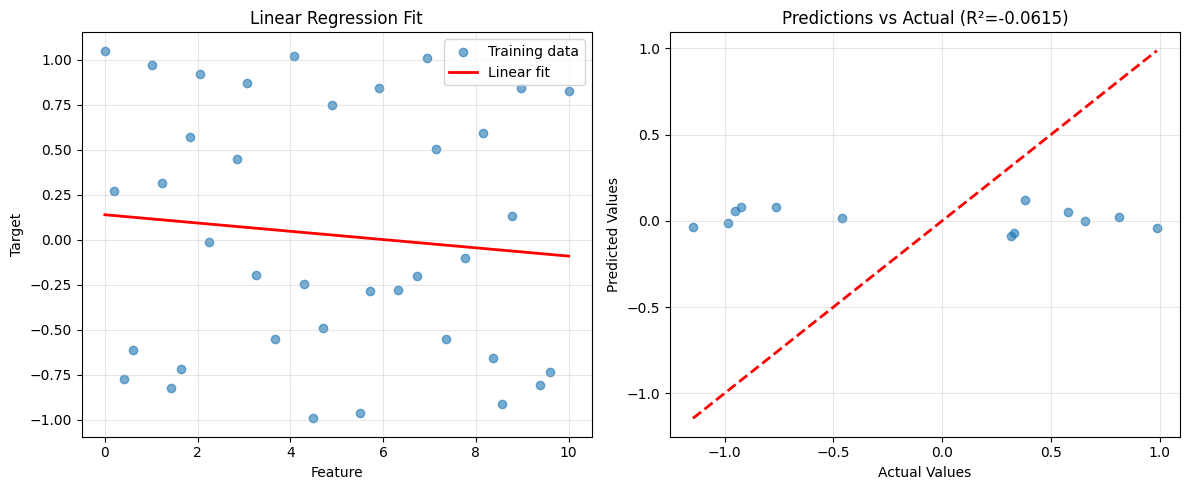

In [9]:
from sklearn.linear_model import LinearRegression  # Import linear regression model

# Create or load regression dataset
X_lr = X_reg  # Use same data as kNN regression
y_lr = y_reg

# Split into train/test sets
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr,  # Features and target
    test_size=0.25,  # 25% for testing
    random_state=42  # Fixed seed for reproducibility
)

# Initialize and train linear regression model
lr = LinearRegression()  # Create linear regression object
lr.fit(X_train_lr, y_train_lr)  # Fit the model to training data

# Get model parameters
print(f"Coefficient (slope): {lr.coef_}")  # Weight/slope of the line
print(f"Intercept: {lr.intercept_}")  # Y-intercept of the line

# Evaluate model
train_score = lr.score(X_train_lr, y_train_lr)  # R² score on training data
test_score = lr.score(X_test_lr, y_test_lr)  # R² score on test data
print(f"Train R²: {train_score:.4f}, Test R²: {test_score:.4f}")

# Make predictions
y_pred_lr = lr.predict(X_test_lr)  # Predict target values for test set

# Visualize
plt.figure(figsize=(12, 5))

# Plot 1: Fit line
plt.subplot(1, 2, 1)
plt.scatter(X_train_lr, y_train_lr, alpha=0.6, label='Training data')
X_line = np.linspace(0, 10, 300).reshape(-1, 1)
y_line = lr.predict(X_line)
plt.plot(X_line, y_line, 'r-', linewidth=2, label='Linear fit')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Predictions vs Actual
plt.subplot(1, 2, 2)
plt.scatter(y_test_lr, y_pred_lr, alpha=0.6)
plt.plot([y_test_lr.min(), y_test_lr.max()], [y_test_lr.min(), y_test_lr.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Predictions vs Actual (R²={test_score:.4f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. RIDGE REGRESSION (L2 Regularization)

Ridge Regression is linear regression with L2 regularization. It adds a penalty 
term (alpha × sum of squared coefficients) to prevent overfitting by shrinking 
large coefficients.

**Formula:**
- Loss = MSE + alpha × ||w||²
- alpha = 0: ordinary linear regression
- alpha → ∞: all coefficients shrink to zero

**Benefits:**
- Reduces overfitting
- Handles multicollinearity
- Shrinks coefficients smoothly

In [10]:
from sklearn.linear_model import Ridge  # Import Ridge regression model

# Initialize Ridge with specific alpha (regularization strength)
ridge = Ridge(alpha=1.0)  # Create Ridge model, alpha=1.0 (default)
ridge.fit(X_train_lr, y_train_lr)  # Train on training data

# Evaluate performance
train_score_ridge = ridge.score(X_train_lr, y_train_lr)  # R² on training data
test_score_ridge = ridge.score(X_test_lr, y_test_lr)  # R² on test data
print(f"Ridge (alpha=1.0) - Train: {train_score_ridge:.4f}, Test: {test_score_ridge:.4f}")

# Compare with Linear Regression
print(f"Linear Regression - Train: {train_score:.4f}, Test: {test_score:.4f}")
print(f"Difference (Ridge R²): {test_score_ridge - test_score:.4f}")

Ridge (alpha=1.0) - Train: 0.0104, Test: -0.0614
Linear Regression - Train: 0.0104, Test: -0.0615
Difference (Ridge R²): 0.0001


Alpha   0.001: Train R²=0.0104, Test R²=-0.0615
Alpha   0.010: Train R²=0.0104, Test R²=-0.0615
Alpha   0.100: Train R²=0.0104, Test R²=-0.0615
Alpha   1.000: Train R²=0.0104, Test R²=-0.0614
Alpha  10.000: Train R²=0.0103, Test R²=-0.0602
Alpha 100.000: Train R²=0.0098, Test R²=-0.0518
Alpha 1000.000: Train R²=0.0046, Test R²=-0.0321


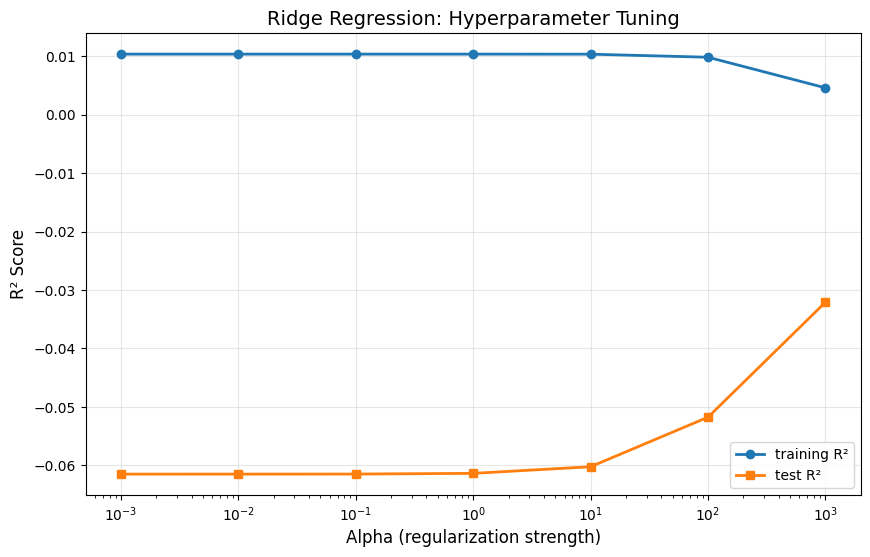


Best alpha: 1000 with test R²: -0.0321


In [11]:
# Test different alpha values
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]  # Different regularization strengths
training_scores_ridge = []
test_scores_ridge = []

for alpha in alphas:
    # Create Ridge with specific alpha
    ridge = Ridge(alpha=alpha)
    
    # Train model
    ridge.fit(X_train_lr, y_train_lr)
    
    # Store performance
    training_scores_ridge.append(ridge.score(X_train_lr, y_train_lr))
    test_scores_ridge.append(ridge.score(X_test_lr, y_test_lr))
    
    # Print for each alpha
    print(f"Alpha {alpha:7.3f}: Train R²={ridge.score(X_train_lr, y_train_lr):.4f}, "
          f"Test R²={ridge.score(X_test_lr, y_test_lr):.4f}")

# Plot results with log scale
plt.figure(figsize=(10, 6))
plt.xscale('log')  # Use logarithmic scale for alpha
plt.plot(alphas, training_scores_ridge, marker='o', label="training R²", linewidth=2)
plt.plot(alphas, test_scores_ridge, marker='s', label="test R²", linewidth=2)
plt.ylabel("R² Score", fontsize=12)
plt.xlabel("Alpha (regularization strength)", fontsize=12)
plt.title("Ridge Regression: Hyperparameter Tuning", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

best_alpha = alphas[np.argmax(test_scores_ridge)]
print(f"\nBest alpha: {best_alpha} with test R²: {max(test_scores_ridge):.4f}")

# 5. LASSO REGRESSION (L1 Regularization)

Lasso (Least Absolute Shrinkage and Selection Operator) is linear regression 
with L1 regularization. It adds a penalty term (alpha × sum of absolute coefficients) 
that can shrink some coefficients to exactly zero, performing feature selection.

**Formula:**
- Loss = MSE + alpha × ||w||₁
- Creates sparsity (zeros in coefficients)
- Automatic feature selection

**Benefits:**
- Feature selection (removes irrelevant features)
- Interpretability
- Handles high-dimensional data

In [12]:
from sklearn.linear_model import Lasso  # Import Lasso model

# Initialize Lasso with specific alpha
lasso = Lasso(alpha=0.1, max_iter=10000)  # max_iter increased to ensure convergence
lasso.fit(X_train_lr, y_train_lr)  # Train on training data

# Evaluate and show feature selection
print(f"Train R²: {lasso.score(X_train_lr, y_train_lr):.4f}")  # Training performance
print(f"Test R²: {lasso.score(X_test_lr, y_test_lr):.4f}")  # Test performance

# For multi-feature data, show feature selection
if X_train_lr.shape[1] > 1:
    n_features_used = np.sum(lasso.coef_ != 0)  # Count non-zero coefficients
    print(f"Features selected: {n_features_used} out of {len(lasso.coef_)}")  # Show selection ratio

Train R²: 0.0080
Test R²: -0.0420


Alpha  0.001: Train R²=0.0104, Test R²=-0.0613
Alpha  0.010: Train R²=0.0103, Test R²=-0.0594
Alpha  0.100: Train R²=0.0080, Test R²=-0.0420
Alpha  1.000: Train R²=0.0000, Test R²=-0.0238
Alpha 10.000: Train R²=0.0000, Test R²=-0.0238


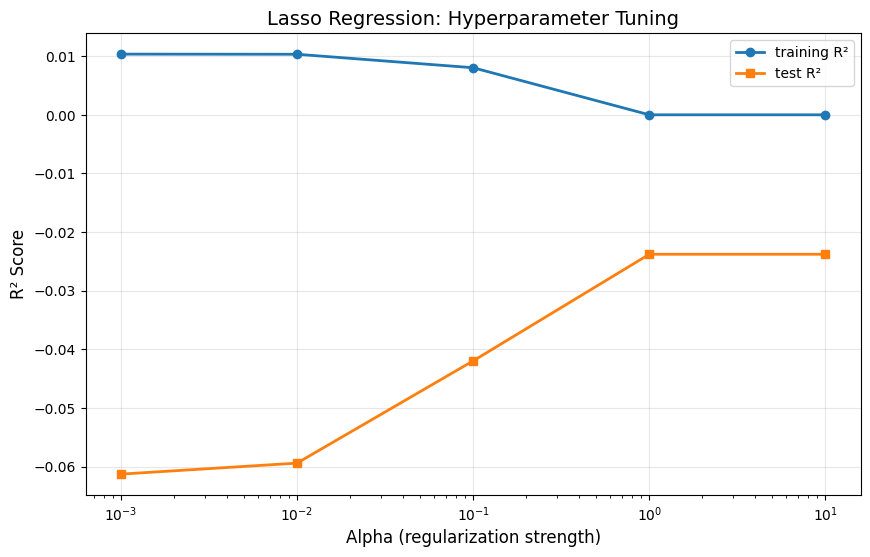

In [13]:
# Test different alpha values for Lasso
alphas_lasso = [0.001, 0.01, 0.1, 1, 10]  # Different regularization strengths
training_scores_lasso = []
test_scores_lasso = []

for alpha in alphas_lasso:
    # Create Lasso with specific alpha
    lasso = Lasso(alpha=alpha, max_iter=100000)
    
    # Train model
    lasso.fit(X_train_lr, y_train_lr)
    
    # Store performance
    train_score_lasso = lasso.score(X_train_lr, y_train_lr)
    test_score_lasso = lasso.score(X_test_lr, y_test_lr)
    training_scores_lasso.append(train_score_lasso)
    test_scores_lasso.append(test_score_lasso)
    
    # Print results
    print(f"Alpha {alpha:6.3f}: Train R²={train_score_lasso:.4f}, Test R²={test_score_lasso:.4f}")

# Plot results
plt.figure(figsize=(10, 6))
plt.xscale('log')  # Logarithmic scale for alpha
plt.plot(alphas_lasso, training_scores_lasso, marker='o', label="training R²", linewidth=2)
plt.plot(alphas_lasso, test_scores_lasso, marker='s', label="test R²", linewidth=2)
plt.ylabel("R² Score", fontsize=12)
plt.xlabel("Alpha (regularization strength)", fontsize=12)
plt.title("Lasso Regression: Hyperparameter Tuning", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# 6. LOGISTIC REGRESSION - CLASSIFICATION

Logistic Regression is a linear classification algorithm that uses the sigmoid 
function to output probabilities between 0 and 1 for binary/multi-class classification.

**Formula:**
- P(y=1) = sigmoid(w₀ + w₁x₁ + w₂x₂ + ... + wₙxₙ)
- sigmoid(z) = 1 / (1 + e^(-z))

**Key Points:**
- Outputs probabilities (0-1)
- Decision boundary at 0.5
- Linear boundary in feature space
- Fast training

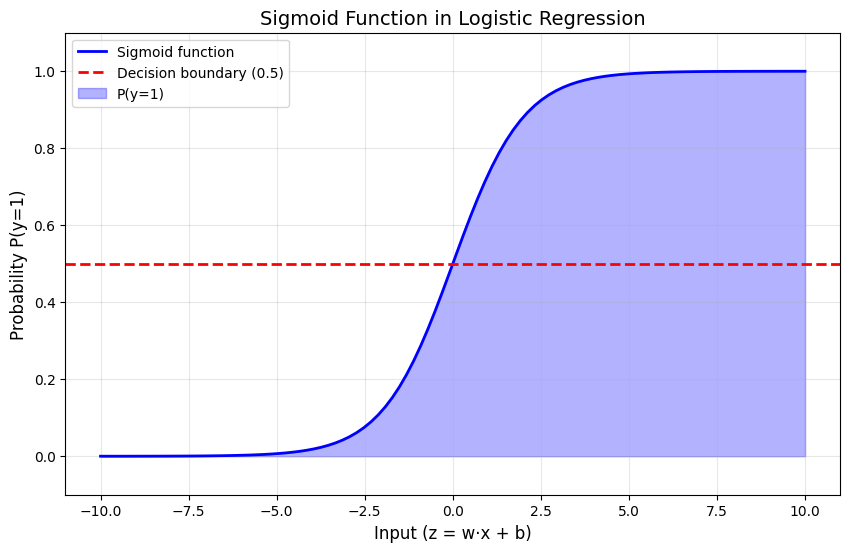

Sigmoid properties:
sigmoid(0) = 0.5000
sigmoid(-5) = 0.0067
sigmoid(5) = 0.9933


In [14]:
# Visualize the sigmoid function
def sigmoid(x):
    """Sigmoid function: converts any value to probability between 0 and 1"""
    return 1 / (1 + np.exp(-x))  # e^(-x) in denominator ensures output is 0-1

# Plot sigmoid curve
x = np.linspace(-10, 10, 100)  # Generate x values from -10 to 10
y = sigmoid(x)  # Apply sigmoid function

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, label="Sigmoid function")  # Plot sigmoid curve
plt.axhline(y=0.5, color='r', linestyle='--', linewidth=2, label="Decision boundary (0.5)")  # 50% threshold
plt.fill_between(x, 0, y, alpha=0.3, color='blue', label="P(y=1)")
plt.xlabel("Input (z = w·x + b)", fontsize=12)  # X-axis is z = w*x + b
plt.ylabel("Probability P(y=1)", fontsize=12)  # Y-axis is probability
plt.title("Sigmoid Function in Logistic Regression", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.ylim(-0.1, 1.1)
plt.show()

print("Sigmoid properties:")
print(f"sigmoid(0) = {sigmoid(0):.4f}")  # Should be 0.5
print(f"sigmoid(-5) = {sigmoid(-5):.4f}")  # Should be close to 0
print(f"sigmoid(5) = {sigmoid(5):.4f}")  # Should be close to 1

In [15]:
from sklearn.linear_model import LogisticRegression  # Import logistic regression
from sklearn.datasets import load_breast_cancer  # Load cancer dataset

# Load classification dataset
cancer = load_breast_cancer()  # Load breast cancer dataset (569 samples, 30 features)
X_clf = cancer.data  # Features (malignant characteristics)
y_clf = cancer.target  # Target (0=malignant, 1=benign)

print(f"Dataset shape: {X_clf.shape}")
print(f"Target distribution: Class 0: {(y_clf==0).sum()}, Class 1: {(y_clf==1).sum()}")

# Split into train/test
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf,  # Features and target
    test_size=0.25,  # 25% for testing
    stratify=y_clf,  # Maintain class distribution
    random_state=42  # Fixed seed
)

# Initialize and train logistic regression
lr_clf = LogisticRegression(C=1.0, max_iter=10000)  # C=1.0 (default regularization)
lr_clf.fit(X_train_clf, y_train_clf)  # Train on training data

# Evaluate
train_score_clf = lr_clf.score(X_train_clf, y_train_clf)  # Accuracy on training data
test_score_clf = lr_clf.score(X_test_clf, y_test_clf)  # Accuracy on test data
print(f"\nLogistic Regression Results:")
print(f"Training Accuracy: {train_score_clf:.4f}")
print(f"Test Accuracy: {test_score_clf:.4f}")

Dataset shape: (569, 30)
Target distribution: Class 0: 212, Class 1: 357

Logistic Regression Results:
Training Accuracy: 0.9577
Test Accuracy: 0.9580


C=  0.001: Train Acc=0.9531, Test Acc=0.9441
C=  0.010: Train Acc=0.9531, Test Acc=0.9510
C=  0.100: Train Acc=0.9507, Test Acc=0.9510
C=  1.000: Train Acc=0.9577, Test Acc=0.9580
C= 10.000: Train Acc=0.9742, Test Acc=0.9650


c:\Users\Tyrese\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=100.000: Train Acc=0.9812, Test Acc=0.9650


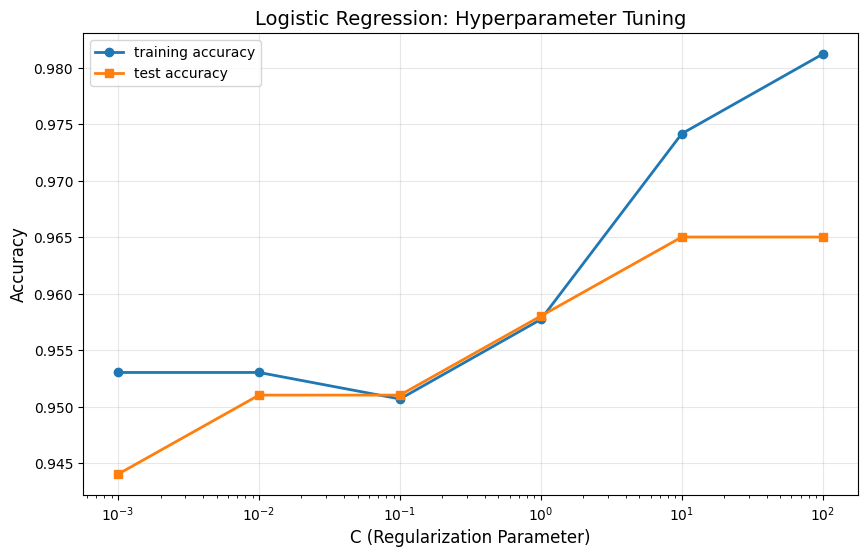


Best C: 10 with test accuracy: 0.9650


In [16]:
# Hyperparameter tuning for C (inverse regularization strength)
# Smaller C = more regularization (stronger penalty)
# Larger C = less regularization (weaker penalty)

C_values = [0.001, 0.01, 0.1, 1, 10, 100]  # C values to test
train_scores_c = []
test_scores_c = []

for C in C_values:
    # Create logistic regression with specific C
    lr_c = LogisticRegression(C=C, max_iter=10000)
    
    # Train model
    lr_c.fit(X_train_clf, y_train_clf)
    
    # Store performance
    train_scores_c.append(lr_c.score(X_train_clf, y_train_clf))
    test_scores_c.append(lr_c.score(X_test_clf, y_test_clf))
    
    # Print results
    print(f"C={C:7.3f}: Train Acc={train_scores_c[-1]:.4f}, Test Acc={test_scores_c[-1]:.4f}")

# Plot results with log scale
plt.figure(figsize=(10, 6))
plt.xscale('log')  # Logarithmic scale for C
plt.plot(C_values, train_scores_c, marker='o', label="training accuracy", linewidth=2)
plt.plot(C_values, test_scores_c, marker='s', label="test accuracy", linewidth=2)
plt.ylabel("Accuracy", fontsize=12)
plt.xlabel("C (Regularization Parameter)", fontsize=12)
plt.title("Logistic Regression: Hyperparameter Tuning", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

best_c = C_values[np.argmax(test_scores_c)]
print(f"\nBest C: {best_c} with test accuracy: {max(test_scores_c):.4f}")

# 7. LINEAR SUPPORT VECTOR MACHINE (LinearSVC)

Linear SVM finds the optimal hyperplane that maximizes the margin between classes.
It's effective for high-dimensional data and handles linear decision boundaries.

**Key Concepts:**
- Finds maximum margin between classes
- Support vectors: data points closest to boundary
- Good for high-dimensional data
- Sensitive to feature scaling

**C Parameter:**
- Small C: larger margin, more tolerance for errors
- Large C: smaller margin, less tolerance for errors

In [17]:
from sklearn.svm import LinearSVC  # Import Linear SVM classifier

# Initialize and train Linear SVC
svm = LinearSVC(C=1.0, max_iter=10000)  # C=1.0 (default)
svm.fit(X_train_clf, y_train_clf)  # Train on training data

# Evaluate
train_score_svm = svm.score(X_train_clf, y_train_clf)  # Accuracy on training data
test_score_svm = svm.score(X_test_clf, y_test_clf)  # Accuracy on test data
print(f"Linear SVC Results:")
print(f"Training Accuracy: {train_score_svm:.4f}")
print(f"Test Accuracy: {test_score_svm:.4f}")

# Compare with Logistic Regression
print(f"\nComparison:")
print(f"Logistic Regression: Train={train_score_clf:.4f}, Test={test_score_clf:.4f}")
print(f"Linear SVC:          Train={train_score_svm:.4f}, Test={test_score_svm:.4f}")

Linear SVC Results:
Training Accuracy: 0.9671
Test Accuracy: 0.9650

Comparison:
Logistic Regression: Train=0.9577, Test=0.9580
Linear SVC:          Train=0.9671, Test=0.9650


C=  0.001: Train Acc=0.9366, Test Acc=0.9301
C=  0.010: Train Acc=0.9484, Test Acc=0.9441
C=  0.100: Train Acc=0.9577, Test Acc=0.9580
C=  1.000: Train Acc=0.9671, Test Acc=0.9650
C= 10.000: Train Acc=0.9671, Test Acc=0.9650
C=100.000: Train Acc=0.9695, Test Acc=0.9580


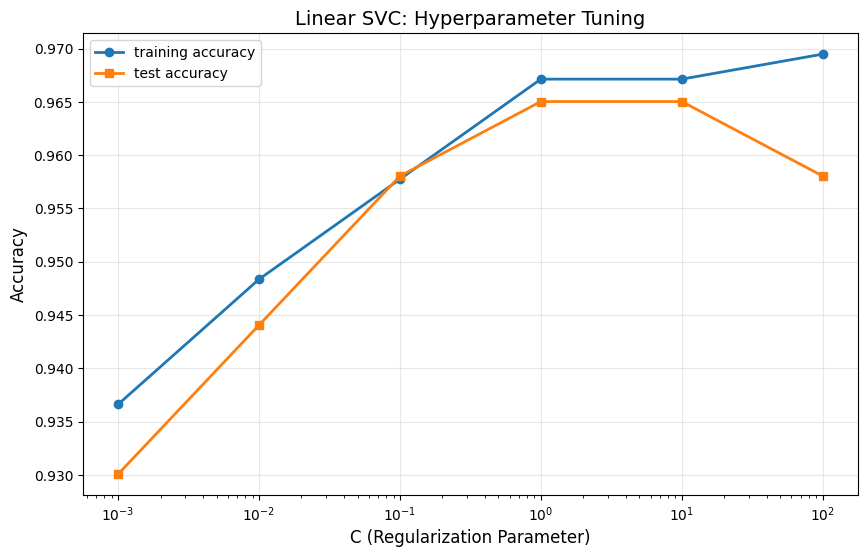

In [18]:
# Hyperparameter tuning for LinearSVC C parameter
C_values_svm = [0.001, 0.01, 0.1, 1, 10, 100]  # C values to test
train_scores_svm = []
test_scores_svm = []

for C in C_values_svm:
    # Create LinearSVC with specific C
    svm_c = LinearSVC(C=C, max_iter=10000)
    
    # Train model
    svm_c.fit(X_train_clf, y_train_clf)
    
    # Store performance
    train_scores_svm.append(svm_c.score(X_train_clf, y_train_clf))
    test_scores_svm.append(svm_c.score(X_test_clf, y_test_clf))
    
    # Print results
    print(f"C={C:7.3f}: Train Acc={train_scores_svm[-1]:.4f}, Test Acc={test_scores_svm[-1]:.4f}")

# Plot results
plt.figure(figsize=(10, 6))
plt.xscale('log')
plt.plot(C_values_svm, train_scores_svm, marker='o', label="training accuracy", linewidth=2)
plt.plot(C_values_svm, test_scores_svm, marker='s', label="test accuracy", linewidth=2)
plt.ylabel("Accuracy", fontsize=12)
plt.xlabel("C (Regularization Parameter)", fontsize=12)
plt.title("Linear SVC: Hyperparameter Tuning", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# 8. DATA CLEANING AND PREPROCESSING

Preprocessing is crucial for preparing raw data for ML algorithms.
This includes handling missing values, encoding categorical variables, and scaling features.

**Key Steps:**
1. Handle missing values
2. Encode categorical variables
3. Scale numerical features
4. Handle outliers
5. Feature engineering

In [19]:
# Create DataFrame with missing values
df_missing = pd.DataFrame({
    'A': [1.0, 5.0, 10.0, np.nan],
    'B': [2.0, 6.0, 11.0, 12.0],
    'C': [3.0, np.nan, 12.0, np.nan],
    'D': [4.0, 8.0, np.nan, np.nan]
})

print("Original DataFrame:")
print(df_missing)
print(f"\nMissing values:\n{df_missing.isnull().sum()}")

# Method 1: Drop rows with any missing values
df_dropped = df_missing.dropna(axis=0)  # Remove rows with NaN
print("\nAfter dropping rows with missing values:")
print(df_dropped)

# Method 2: Drop columns with any missing values
df_dropped_cols = df_missing.dropna(axis=1)  # Remove columns with NaN
print("\nAfter dropping columns with missing values:")
print(df_dropped_cols)

# Method 3: Impute missing values with mean
imputer = SimpleImputer(strategy='mean')  # Create imputer (mean of column)
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_missing),  # Fit imputer and transform data
    columns=df_missing.columns  # Keep original column names
)
print("\nAfter imputation with mean:")
print(df_imputed)

# Method 4: Impute with different strategies
imputer_median = SimpleImputer(strategy='median')  # Use median instead
imputer_mode = SimpleImputer(strategy='most_frequent')  # Use mode for categorical

Original DataFrame:
      A     B     C    D
0   1.0   2.0   3.0  4.0
1   5.0   6.0   NaN  8.0
2  10.0  11.0  12.0  NaN
3   NaN  12.0   NaN  NaN

Missing values:
A    1
B    0
C    2
D    2
dtype: int64

After dropping rows with missing values:
     A    B    C    D
0  1.0  2.0  3.0  4.0

After dropping columns with missing values:
      B
0   2.0
1   6.0
2  11.0
3  12.0

After imputation with mean:
           A     B     C    D
0   1.000000   2.0   3.0  4.0
1   5.000000   6.0   7.5  8.0
2  10.000000  11.0  12.0  6.0
3   5.333333  12.0   7.5  6.0


In [20]:
# Create sample data with categorical variables
df_categorical = pd.DataFrame({
    'color': ['red', 'green', 'blue', 'red', 'green'],
    'size': ['S', 'M', 'L', 'M', 'S'],
    'price': [10.5, 20.0, 30.5, 15.0, 25.0]
})

print("Original DataFrame:")
print(df_categorical)

# Method 1: Manual mapping (for ordinal variables)
size_mapping = {'S': 0, 'M': 1, 'L': 2}  # Create mapping dictionary
df_cat1 = df_categorical.copy()
df_cat1['size_encoded'] = df_cat1['size'].map(size_mapping)  # Apply mapping
print("\nAfter manual mapping (size):")
print(df_cat1)

# Method 2: LabelEncoder (for target or ordinal encoding)
le = LabelEncoder()  # Create encoder object
df_cat2 = df_categorical.copy()
df_cat2['color_label'] = le.fit_transform(df_cat2['color'])  # Encode color
print("\nAfter LabelEncoder:")
print(df_cat2)

# Method 3: One-Hot Encoding (for nominal variables)
df_cat3 = df_categorical.copy()
# Using pandas get_dummies (simpler)
df_dummies = pd.get_dummies(df_cat3[['color']], prefix='color', drop_first=False)
print("\nAfter One-Hot Encoding:")
print(df_dummies)

# One-hot encoding with drop_first=True (avoid multicollinearity)
df_dummies_drop = pd.get_dummies(df_cat3[['color']], prefix='color', drop_first=True)
print("\nAfter One-Hot Encoding (drop_first=True):")
print(df_dummies_drop)

Original DataFrame:
   color size  price
0    red    S   10.5
1  green    M   20.0
2   blue    L   30.5
3    red    M   15.0
4  green    S   25.0

After manual mapping (size):
   color size  price  size_encoded
0    red    S   10.5             0
1  green    M   20.0             1
2   blue    L   30.5             2
3    red    M   15.0             1
4  green    S   25.0             0

After LabelEncoder:
   color size  price  color_label
0    red    S   10.5            2
1  green    M   20.0            1
2   blue    L   30.5            0
3    red    M   15.0            2
4  green    S   25.0            1

After One-Hot Encoding:
   color_blue  color_green  color_red
0       False        False       True
1       False         True      False
2        True        False      False
3       False        False       True
4       False         True      False

After One-Hot Encoding (drop_first=True):
   color_green  color_red
0        False       True
1         True      False
2        False 

In [21]:
# Create sample data for scaling
X_scaling = np.array([
    [1, 100],
    [2, 200],
    [3, 300],
    [4, 400]
], dtype=float)

print("Original data:")
print(X_scaling)
print(f"Range: Feature 1: [{X_scaling[:, 0].min()}, {X_scaling[:, 0].max()}]")
print(f"       Feature 2: [{X_scaling[:, 1].min()}, {X_scaling[:, 1].max()}]")

# Method 1: MinMaxScaler (scale to [0, 1])
minmax_scaler = MinMaxScaler()  # Create MinMaxScaler
X_minmax = minmax_scaler.fit_transform(X_scaling)  # Fit and transform
print("\nAfter MinMaxScaler (range [0, 1]):")
print(X_minmax)

# Method 2: StandardScaler (standardize to mean=0, std=1)
standard_scaler = StandardScaler()  # Create StandardScaler
X_std = standard_scaler.fit_transform(X_scaling)  # Fit and transform
print("\nAfter StandardScaler (mean=0, std=1):")
print(X_std)
print(f"Mean: {X_std.mean(axis=0)}")  # Should be close to [0, 0]
print(f"Std:  {X_std.std(axis=0)}")  # Should be close to [1, 1]

# Important: Fit on training data, transform test data
print("\n--- Correct approach for train/test split ---")
X_train_scale, X_test_scale = train_test_split(X_scaling, test_size=0.5, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_scale)  # Fit on TRAINING data only
X_test_scaled = scaler.transform(X_test_scale)  # Transform test data using same scaler
print(f"Training data scaled: {X_train_scaled}")
print(f"Test data scaled: {X_test_scaled}")

Original data:
[[  1. 100.]
 [  2. 200.]
 [  3. 300.]
 [  4. 400.]]
Range: Feature 1: [1.0, 4.0]
       Feature 2: [100.0, 400.0]

After MinMaxScaler (range [0, 1]):
[[0.         0.        ]
 [0.33333333 0.33333333]
 [0.66666667 0.66666667]
 [1.         1.        ]]

After StandardScaler (mean=0, std=1):
[[-1.34164079 -1.34164079]
 [-0.4472136  -0.4472136 ]
 [ 0.4472136   0.4472136 ]
 [ 1.34164079  1.34164079]]
Mean: [0. 0.]
Std:  [1. 1.]

--- Correct approach for train/test split ---
Training data scaled: [[-1. -1.]
 [ 1.  1.]]
Test data scaled: [[0. 0.]
 [2. 2.]]


# 9. MODEL EVALUATION

Proper model evaluation is critical for assessing generalization performance
and detecting overfitting/underfitting.

**Key Evaluation Strategies:**
1. Train-Validation-Test Split
2. K-Fold Cross-Validation
3. Confusion Matrix
4. Classification Metrics (Precision, Recall, F1)
5. ROC-AUC Curves

In [22]:
# Split data into 3 parts: train (60%), validation (20%), test (20%)
# First split: 80% train+val, 20% test
X_temp, X_test_eval, y_temp, y_test_eval = train_test_split(
    X_clf, y_clf,  # Original data
    test_size=0.2,  # 20% for final test
    random_state=42  # Fixed seed
)

# Second split: 60% train, 20% validation (from the remaining 80%)
X_train_eval, X_val_eval, y_train_eval, y_val_eval = train_test_split(
    X_temp, y_temp,  # 80% of data
    test_size=0.25,  # 25% of remaining = 20% of total
    random_state=42  # Fixed seed
)

# Now we have three sets:
print(f"Training set:   {X_train_eval.shape[0]} samples (60%)")
print(f"Validation set: {X_val_eval.shape[0]} samples (20%)")
print(f"Test set:       {X_test_eval.shape[0]} samples (20%)")

# Train on training set, tune hyperparameters on validation set,
# evaluate on test set
model_eval = LogisticRegression(max_iter=10000)
model_eval.fit(X_train_eval, y_train_eval)

train_score_eval = model_eval.score(X_train_eval, y_train_eval)
val_score_eval = model_eval.score(X_val_eval, y_val_eval)
test_score_eval = model_eval.score(X_test_eval, y_test_eval)

print(f"\nModel Performance:")
print(f"Training Accuracy:   {train_score_eval:.4f}")
print(f"Validation Accuracy: {val_score_eval:.4f}")
print(f"Test Accuracy:       {test_score_eval:.4f}")

Training set:   341 samples (60%)
Validation set: 114 samples (20%)
Test set:       114 samples (20%)

Model Performance:
Training Accuracy:   0.9589
Validation Accuracy: 0.9649
Test Accuracy:       0.9649


In [23]:
# Create K-Fold splitter
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold CV

# Perform k-fold cross-validation manually
fold_scores = []  # Store score for each fold
fold_num = 1

for train_idx, test_idx in kf.split(X_clf):
    # Get train and test indices for this fold
    X_train_fold = X_clf[train_idx]  # Training samples for this fold
    X_test_fold = X_clf[test_idx]  # Test samples for this fold
    y_train_fold = y_clf[train_idx]  # Training targets for this fold
    y_test_fold = y_clf[test_idx]  # Test targets for this fold
    
    # Train and evaluate model on this fold
    model_fold = LogisticRegression(max_iter=10000)  # Create fresh model
    model_fold.fit(X_train_fold, y_train_fold)  # Train on fold's training data
    fold_score = model_fold.score(X_test_fold, y_test_fold)  # Evaluate on fold's test data
    fold_scores.append(fold_score)  # Store score
    print(f"Fold {fold_num}: {fold_score:.4f}")  # Print fold score
    fold_num += 1

# Calculate mean and std of all folds
mean_cv_score = np.mean(fold_scores)  # Average CV score
std_cv_score = np.std(fold_scores)  # Standard deviation
print(f"\nMean CV Score: {mean_cv_score:.4f} (+/- {std_cv_score:.4f})")  # Print summary
print(f"Individual fold scores: {[f'{s:.4f}' for s in fold_scores]}")

Fold 1: 0.9561
Fold 2: 0.9649
Fold 3: 0.9386
Fold 4: 0.9737
Fold 5: 0.9204

Mean CV Score: 0.9507 (+/- 0.0191)
Individual fold scores: ['0.9561', '0.9649', '0.9386', '0.9737', '0.9204']


Confusion Matrix:
[[40  3]
 [ 1 70]]

True Negatives (TN):   40
False Positives (FP):  3
False Negatives (FN):  1
True Positives (TP):   70


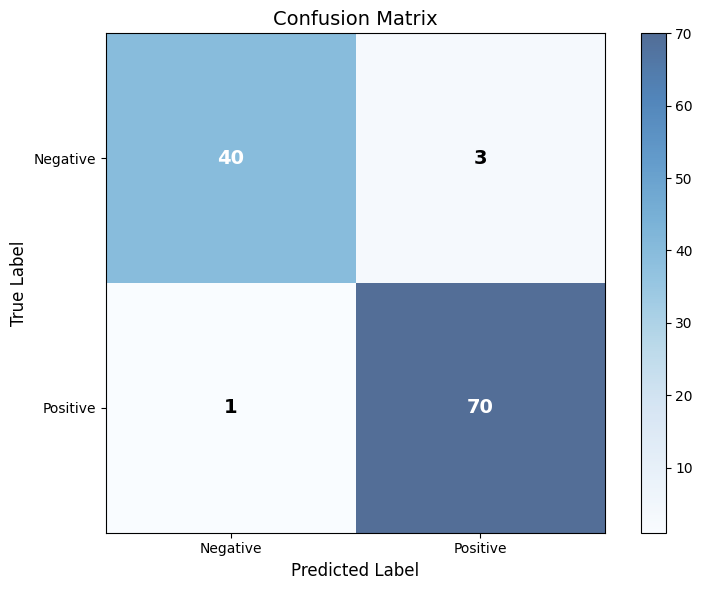


Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.93      0.95        43
    Positive       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [24]:
# Make predictions on test set
y_pred_eval = model_eval.predict(X_test_eval)

# Create confusion matrix
confmat = confusion_matrix(y_true=y_test_eval, y_pred=y_pred_eval)

print("Confusion Matrix:")
print(confmat)
print(f"\nTrue Negatives (TN):   {confmat[0, 0]}")  # Correctly predicted 0s
print(f"False Positives (FP):  {confmat[0, 1]}")  # Predicted 1 but was 0
print(f"False Negatives (FN):  {confmat[1, 0]}")  # Predicted 0 but was 1
print(f"True Positives (TP):   {confmat[1, 1]}")  # Correctly predicted 1s

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
im = plt.imshow(confmat, cmap='Blues', alpha=0.7)
plt.colorbar(im)
for i in range(confmat.shape[0]):  # Loop through rows
    for j in range(confmat.shape[1]):  # Loop through columns
        plt.text(x=j, y=i, s=confmat[i, j], va='center', ha='center',
                color='white' if confmat[i, j] > confmat.max()/2 else 'black',
                fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.yticks([0, 1], ['Negative', 'Positive'])
plt.tight_layout()
plt.show()

# Print classification report (includes Precision, Recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test_eval, y_pred_eval, 
                          target_names=['Negative', 'Positive']))

# 10. COMPLETE ML WORKFLOW

A comprehensive example combining all steps:
1. Load and explore data
2. Split into train/test
3. Preprocess and scale
4. Train multiple models
5. Tune hyperparameters
6. Evaluate and compare
7. Make predictions

COMPLETE ML WORKFLOW

1. SPLITTING DATA
   Training set:  426 samples (75%)
   Test set:      143 samples (25%)

2. PREPROCESSING (Scaling)
   Features scaled to mean=0, std=1

3. TRAINING MODELS
   Logistic Regression:
      Train: 0.9883, Test: 0.9860
   Linear SVC:
      Train: 0.9906, Test: 0.9720
   kNN (k=5):
      Train: 0.9695, Test: 0.9790

4. MODEL COMPARISON


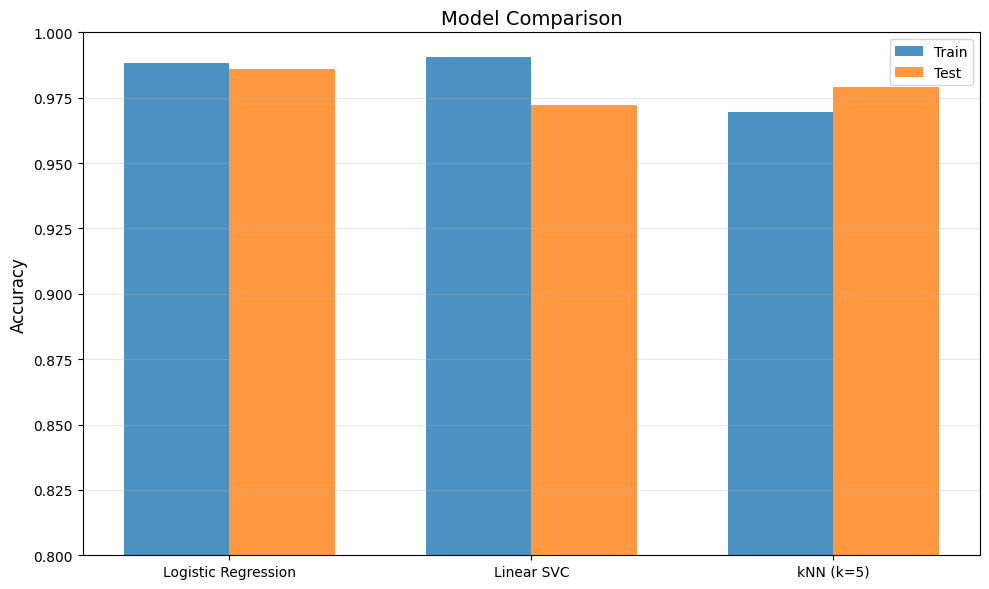


5. BEST MODEL
   Best Model: Logistic Regression
   Test Accuracy: 0.9860

   Confusion Matrix:
   True Negatives:  52
   False Positives: 1
   False Negatives: 1
   True Positives:  89


In [25]:
def complete_ml_workflow(X, y, test_size=0.25, random_state=42):
    """
    Complete ML workflow from raw data to model evaluation
    
    Parameters:
    - X: Feature matrix
    - y: Target vector
    - test_size: Proportion of data for testing
    - random_state: Seed for reproducibility
    
    Returns:
    - Dictionary with results and models
    """
    
    print("=" * 60)
    print("COMPLETE ML WORKFLOW")
    print("=" * 60)
    
    # Step 1: Split data
    print("\n1. SPLITTING DATA")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y  # Maintain class distribution
    )
    print(f"   Training set:  {X_train.shape[0]} samples ({(1-test_size)*100:.0f}%)")
    print(f"   Test set:      {X_test.shape[0]} samples ({test_size*100:.0f}%)")
    
    # Step 2: Preprocess and scale
    print("\n2. PREPROCESSING (Scaling)")
    scaler = StandardScaler()  # Create scaler
    X_train_scaled = scaler.fit_transform(X_train)  # Fit on training data
    X_test_scaled = scaler.transform(X_test)  # Transform test data
    print("   Features scaled to mean=0, std=1")
    
    # Step 3: Train multiple models
    print("\n3. TRAINING MODELS")
    models = {
        'Logistic Regression': LogisticRegression(max_iter=10000),
        'Linear SVC': LinearSVC(max_iter=10000),
        'kNN (k=5)': KNeighborsClassifier(n_neighbors=5)
    }
    
    results = {}
    for model_name, model in models.items():
        # Train model
        model.fit(X_train_scaled, y_train)
        
        # Evaluate
        train_score = model.score(X_train_scaled, y_train)
        test_score = model.score(X_test_scaled, y_test)
        
        results[model_name] = {
            'model': model,
            'train_score': train_score,
            'test_score': test_score
        }
        
        print(f"   {model_name}:")
        print(f"      Train: {train_score:.4f}, Test: {test_score:.4f}")
    
    # Step 4: Visualize comparison
    print("\n4. MODEL COMPARISON")
    model_names = list(results.keys())
    train_scores = [results[m]['train_score'] for m in model_names]
    test_scores = [results[m]['test_score'] for m in model_names]
    
    x = np.arange(len(model_names))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, train_scores, width, label='Train', alpha=0.8)
    ax.bar(x + width/2, test_scores, width, label='Test', alpha=0.8)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Model Comparison', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.legend()
    ax.set_ylim([0.8, 1.0])
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    # Step 5: Best model analysis
    print("\n5. BEST MODEL")
    best_model_name = max(results, key=lambda x: results[x]['test_score'])
    best_result = results[best_model_name]
    best_model = best_result['model']
    
    print(f"   Best Model: {best_model_name}")
    print(f"   Test Accuracy: {best_result['test_score']:.4f}")
    
    # Make predictions and show confusion matrix
    y_pred = best_model.predict(X_test_scaled)
    confmat = confusion_matrix(y_test, y_pred)
    
    print(f"\n   Confusion Matrix:")
    print(f"   True Negatives:  {confmat[0, 0]}")
    print(f"   False Positives: {confmat[0, 1]}")
    print(f"   False Negatives: {confmat[1, 0]}")
    print(f"   True Positives:  {confmat[1, 1]}")
    
    return {
        'results': results,
        'best_model_name': best_model_name,
        'best_model': best_model,
        'scaler': scaler,
        'X_test_scaled': X_test_scaled,
        'y_test': y_test
    }

# Run complete workflow
workflow_results = complete_ml_workflow(X_clf, y_clf)

In [26]:
# Using the trained model to make predictions on new data
print("MAKING PREDICTIONS ON NEW DATA")
print("=" * 60)

# Get the best model and scaler from workflow
best_model = workflow_results['best_model']
scaler = workflow_results['scaler']

# Create a new sample (use feature means as example)
new_sample = X_clf.mean(axis=0).reshape(1, -1)  # Mean of all features
print(f"\nNew sample (feature means):")
print(new_sample)

# Preprocess new sample using the same scaler
new_sample_scaled = scaler.transform(new_sample)
print(f"\nScaled sample:")
print(new_sample_scaled)

# Make prediction
prediction = best_model.predict(new_sample_scaled)
prediction_proba = best_model.predict_proba(new_sample_scaled)

print(f"\nPrediction: {prediction[0]}")
print(f"Prediction Probabilities:")
print(f"   Class 0 (Malignant): {prediction_proba[0, 0]:.4f}")
print(f"   Class 1 (Benign):    {prediction_proba[0, 1]:.4f}")

MAKING PREDICTIONS ON NEW DATA

New sample (feature means):
[[1.41272917e+01 1.92896485e+01 9.19690334e+01 6.54889104e+02
  9.63602812e-02 1.04340984e-01 8.87993158e-02 4.89191459e-02
  1.81161863e-01 6.27976098e-02 4.05172056e-01 1.21685343e+00
  2.86605923e+00 4.03370791e+01 7.04097891e-03 2.54781388e-02
  3.18937163e-02 1.17961371e-02 2.05422988e-02 3.79490387e-03
  1.62691898e+01 2.56772232e+01 1.07261213e+02 8.80583128e+02
  1.32368594e-01 2.54265044e-01 2.72188483e-01 1.14606223e-01
  2.90075571e-01 8.39458172e-02]]

Scaled sample:
[[ 0.01486244 -0.00121516  0.01557018  0.01522827  0.02568973  0.01675558
  -0.00162472  0.01841604  0.03474109  0.0025339   0.023757    0.00549759
   0.02100293  0.02823906 -0.0121656  -0.00564407 -0.01838867  0.02234271
  -0.02796554 -0.00672793  0.01387692 -0.0049246   0.01369318  0.01442976
   0.00014745 -0.01095027 -0.02518432  0.00670267 -0.0173681  -0.00713653]]

Prediction: 1
Prediction Probabilities:
   Class 0 (Malignant): 0.4602
   Class 1 (

# KEY TAKEAWAYS & BEST PRACTICES

## Algorithm Selection Guide

| Algorithm | Task | When to Use | Pros | Cons |
|-----------|------|-------------|------|------|
| **kNN** | Classification/Regression | Small data, non-linear patterns | Simple, non-parametric | Slow predictions, sensitive to scaling |
| **Linear Regression** | Regression | Linear relationships | Fast, interpretable | Assumes linearity, sensitive to outliers |
| **Ridge** | Regression | Multicollinearity | Handles correlated features | Not feature selection |
| **Lasso** | Regression | Feature selection needed | Automatic selection, interpretable | Less stable than Ridge |
| **Logistic Regression** | Classification | Linear boundaries | Fast, probabilistic, interpretable | Assumes linear boundary |
| **Linear SVM** | Classification | High dimensions | Works well in high-D, margin-based | Less interpretable than Logistic |

## Preprocessing Checklist

- [ ] Handle missing values (drop/impute)
- [ ] Encode categorical variables (one-hot/label)
- [ ] Scale numerical features (StandardScaler/MinMaxScaler)
- [ ] Check for outliers
- [ ] Feature engineering if needed
- [ ] Check class imbalance (for classification)

## Evaluation Best Practices

- [ ] Always use stratified splits for imbalanced data
- [ ] Use K-Fold Cross-Validation for robust estimates
- [ ] Tune hyperparameters on validation set, evaluate on test set
- [ ] Use appropriate metrics (accuracy, precision, recall, F1, ROC-AUC)
- [ ] Compare multiple models before choosing

## Common Mistakes to Avoid

1. **Leakage**: Using test set information during training
2. **Wrong Scaling**: Fit scaler on training data only
3. **Skipping Validation**: Always use separate validation set
4. **Ignoring Class Imbalance**: Use stratified splitting
5. **Overfitting**: Too complex models with small data
6. **Underfitting**: Too simple models for complex data

## Model Development Workflow

1. **Explore** → Understand the data
2. **Clean** → Handle missing/categorical values
3. **Scale** → Normalize features
4. **Split** → Train/validation/test sets
5. **Train** → Multiple models
6. **Evaluate** → Use appropriate metrics
7. **Tune** → Hyperparameter optimization
8. **Compare** → Select best model
9. **Deploy** → Make predictions on new data

## Resources for Further Learning

- scikit-learn documentation: https://scikit-learn.org
- Feature scaling: https://en.wikipedia.org/wiki/Feature_scaling
- Cross-validation: https://scikit-learn.org/stable/modules/cross_validation.html
- Model evaluation: https://scikit-learn.org/stable/modules/model_evaluation.html